Found 5 video file(s):
  [0] VID00051.AVI
  [1] VID00052.AVI
  [2] VID00053.AVI
  [3] VID00054.AVI
  [4] VID00055.AVI

--- Dataset Split ---
Train/Tune Videos (4): ['VID00051.AVI', 'VID00052.AVI', 'VID00053.AVI', 'VID00054.AVI']
Holdout Eval Video (1): VID00055.AVI

=== VIDEO METADATA TABLE ===


,Filename,Resolution,FPS,Total Frames,Duration (s),Codec,Size (MB)
0,VID00051.AVI,640x480,25.00,4502,180.06,MJPG,153.28
1,VID00052.AVI,640x480,24.99,2570,102.83,MJPG,70.43
2,VID00053.AVI,640x480,25.00,4501,180.04,MJPG,113.76
3,VID00054.AVI,640x480,24.99,4501,180.10,MJPG,105.46
4,VID00055.AVI,640x480,25.00,4502,180.09,MJPG,102.79



=== CONTAINER STREAM & TELEMETRY CHECK ===

File: VID00051.AVI
FFprobe not available or failed to run.

File: VID00052.AVI
FFprobe not available or failed to run.

File: VID00053.AVI
FFprobe not available or failed to run.

File: VID00054.AVI
FFprobe not available or failed to run.

File: VID00055.AVI
FFprobe not available or failed to run.

=== VISUAL FRAME INSPECTION (Checking for On-Screen Display / OSD Telemetry) ===


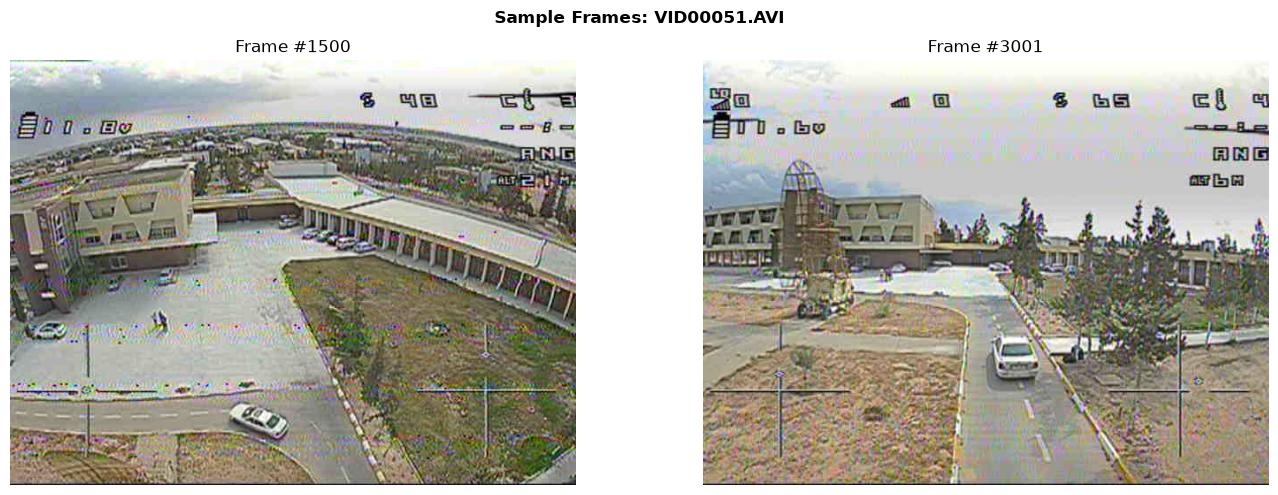

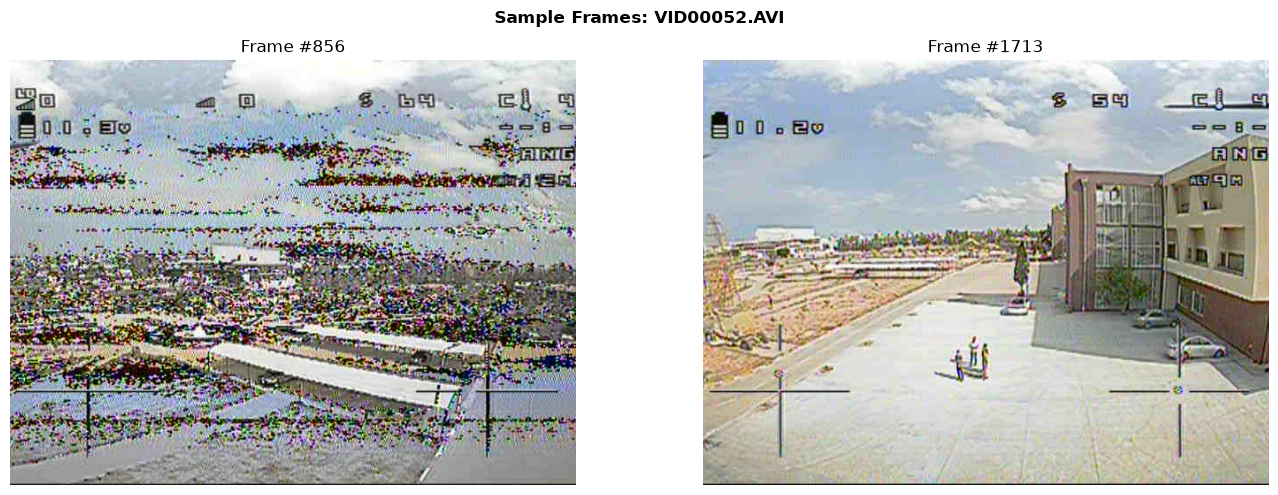

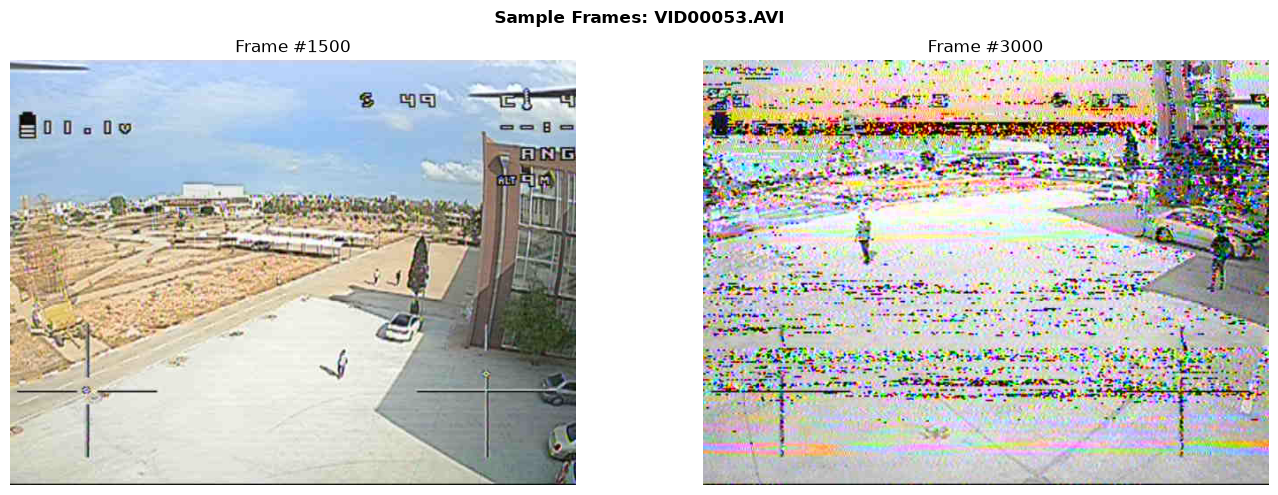

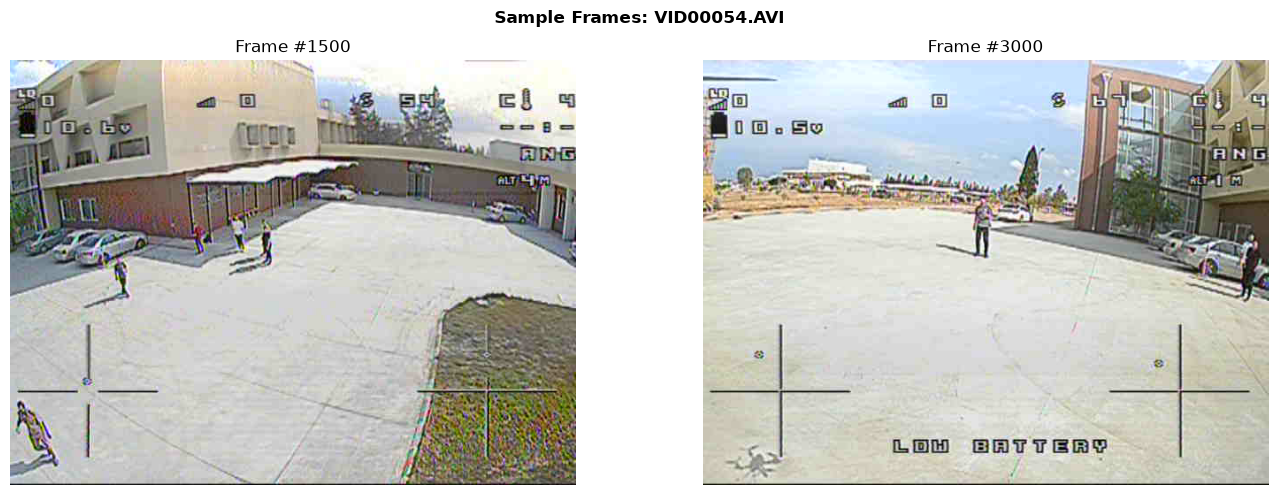

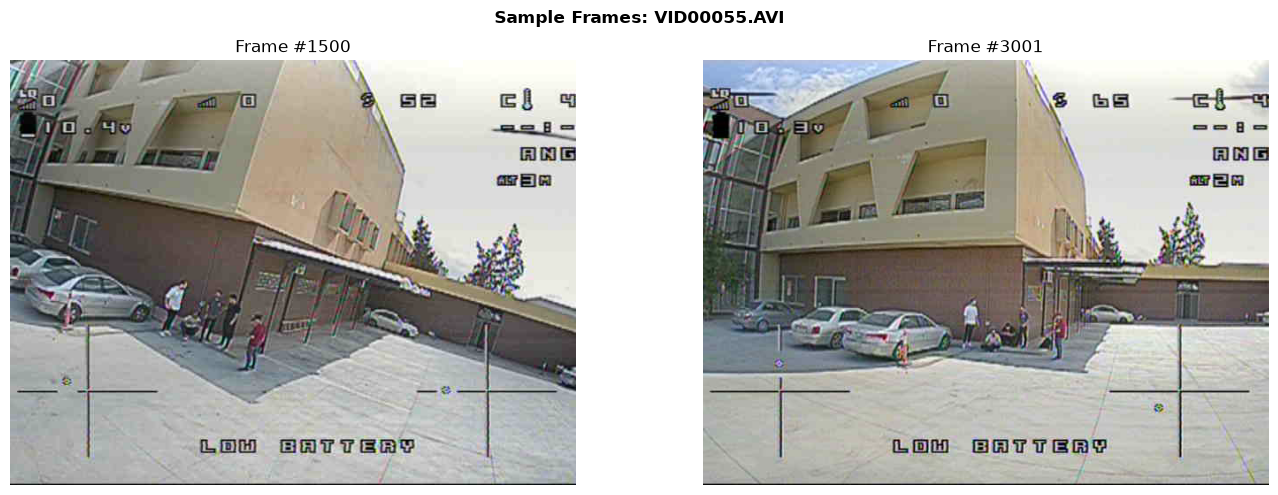

In [1]:
import cv2
import os
import glob
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration & File Discovery ---
VIDEO_DIR = r"C:\Users\PC-LAB1\img_processing_lab\videos"  # Set path to your video folder if different
video_files = sorted(glob.glob(os.path.join(VIDEO_DIR, "*.avi")))

if not video_files:
    raise FileNotFoundError(f"No .avi files found in {os.path.abspath(VIDEO_DIR)}. Please verify the path.")

print(f"Found {len(video_files)} video file(s):")
for idx, f in enumerate(video_files):
    print(f"  [{idx}] {os.path.basename(f)}")

# Define 4/1 Dataset Split (First 4 for training/tuning, 5th for holdout evaluation)
TRAIN_TUNE_VIDEOS = video_files[:4]
HOLDOUT_EVAL_VIDEO = video_files[4] if len(video_files) >= 5 else video_files[-1]

print("\n--- Dataset Split ---")
print(f"Train/Tune Videos ({len(TRAIN_TUNE_VIDEOS)}): {[os.path.basename(f) for f in TRAIN_TUNE_VIDEOS]}")
print(f"Holdout Eval Video (1): {os.path.basename(HOLDOUT_EVAL_VIDEO)}")

# --- Metadata Extraction Function ---
def inspect_video_file(video_path):
    """Extracts OpenCV properties and checks container metadata."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {"file": os.path.basename(video_path), "status": "Failed to open"}

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc_int = int(cap.get(cv2.CAP_PROP_FOURCC))
    
    # Decode FOURCC codec code
    fourcc = "".join([chr((fourcc_int >> 8 * i) & 0xFF) for i in range(4)])
    duration_sec = total_frames / fps if fps > 0 else 0
    file_size_mb = os.path.getsize(video_path) / (1024 * 1024)

    cap.release()

    return {
        "Filename": os.path.basename(video_path),
        "Resolution": f"{width}x{height}",
        "FPS": round(fps, 2),
        "Total Frames": total_frames,
        "Duration (s)": round(duration_sec, 2),
        "Codec": fourcc,
        "Size (MB)": round(file_size_mb, 2)
    }

# Run metadata extraction across all videos
metadata_list = [inspect_video_file(vf) for vf in video_files]
df_metadata = pd.DataFrame(metadata_list)

print("\n=== VIDEO METADATA TABLE ===")
display(df_metadata)

# --- Telemetry & Subtitle Stream Inspector (FFprobe check) ---
print("\n=== CONTAINER STREAM & TELEMETRY CHECK ===")
def check_embedded_streams(video_path):
    """Uses ffprobe to detect non-video streams (telemetry, subtitles, data)."""
    try:
        cmd = [
            "ffprobe", "-v", "error",
            "-show_entries", "stream=index,codec_type,codec_name",
            "-of", "default=noprint_wrappers=1", video_path
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        return result.stdout.strip()
    except Exception:
        return "FFprobe not available or failed to run."

for vf in video_files:
    streams_info = check_embedded_streams(vf)
    print(f"\nFile: {os.path.basename(vf)}")
    print(streams_info if streams_info else "Only standard streams detected.")

# --- Visual OSD Telemetry Inspection ---
print("\n=== VISUAL FRAME INSPECTION (Checking for On-Screen Display / OSD Telemetry) ===")

def sample_frames_from_video(video_path, num_samples=3):
    """Extracts evenly spaced sample frames from a video."""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = [int(total_frames * (i / (num_samples + 1))) for i in range(1, num_samples + 1)]
    
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append((idx, frame_rgb))
    cap.release()
    return frames

# Display 2 sample frames per video to check for burned-in telemetry overlays
for vf in video_files:
    sampled = sample_frames_from_video(vf, num_samples=2)
    fig, axes = plt.subplots(1, len(sampled), figsize=(14, 5))
    fig.suptitle(f"Sample Frames: {os.path.basename(vf)}", fontsize=12, fontweight='bold')
    
    if len(sampled) == 1:
        axes = [axes]
        
    for ax, (frame_idx, img) in zip(axes, sampled):
        ax.imshow(img)
        ax.set_title(f"Frame #{frame_idx}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Current Working Directory: C:\Users\PC-LAB1\img_processing_lab\videos

Holdout Evaluation Video (Locked): VID00052.AVI
Train/Tune Videos (4): ['VID00051.AVI', 'VID00053.AVI', 'VID00054.AVI', 'VID00055.AVI']

Extracting frames for fine-tuning dataset...
Extraction complete! Saved 361 clean sample frames to 'C:\Users\PC-LAB1\img_processing_lab\videos\dataset_samples\images'

Loading models...
Successfully loaded VisDrone weights from: ./visdrone.pt
Running baseline visual comparison on frame: VID00051_frame_00000.jpg


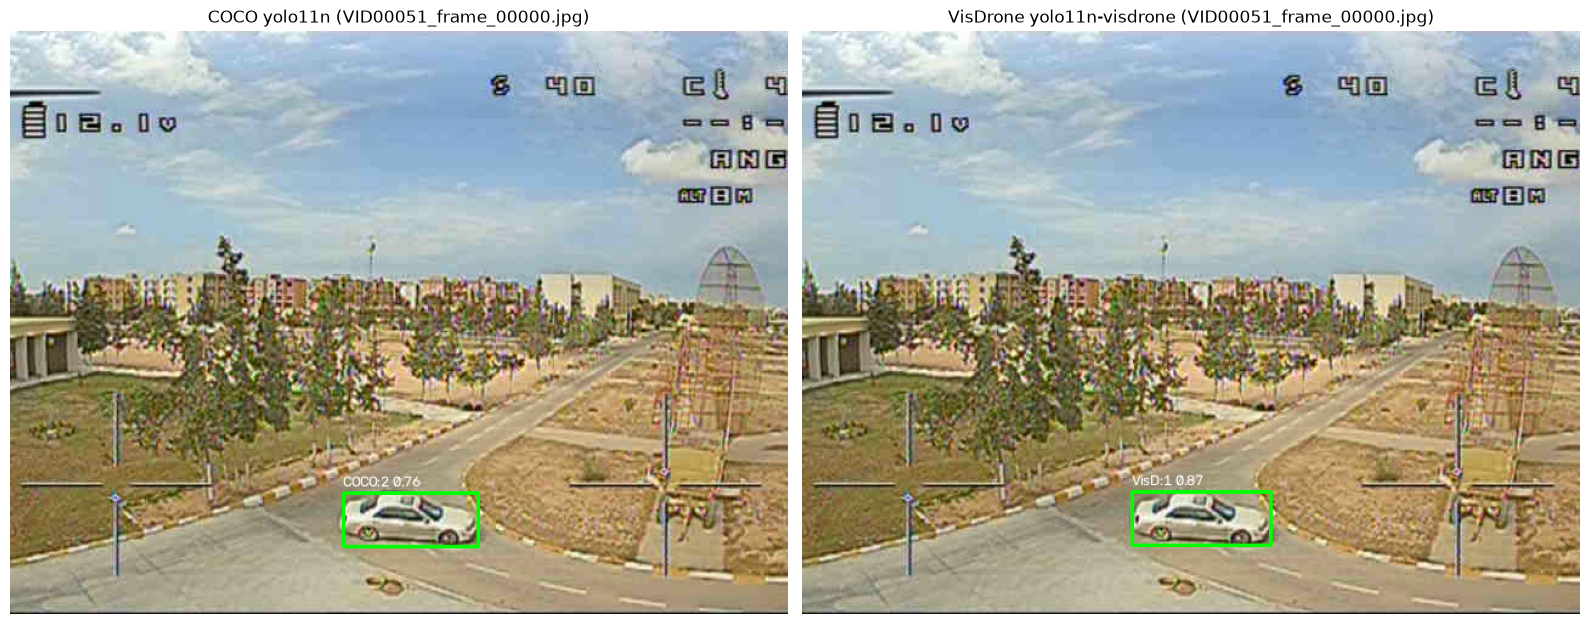

In [5]:
import cv2
import os
import glob
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- Step 0: Ensure Working Directory & Path Discovery ---
# Change '.' to your specific path if videos are stored in a subfolder (e.g., './videos')
SEARCH_DIR = os.path.abspath(r"C:\Users\PC-LAB1\img_processing_lab\videos")

print(f"Current Working Directory: {SEARCH_DIR}")

# Find all files matching .avi or .AVI (case-insensitive search)
all_files = os.listdir(SEARCH_DIR)
all_videos = [
    os.path.join(SEARCH_DIR, f) for f in all_files 
    if f.lower().endswith(".avi")
]

if not all_videos:
    print("\n--- DEBUG: FILE LISTING ---")
    print("No .avi/.AVI files found. Here are the files present in your directory:")
    print(all_files[:10])  # Show first 10 files for quick inspection
    raise FileNotFoundError(
        f"No .avi files detected in '{SEARCH_DIR}'. "
        "Please check if the video files are in a subdirectory or update SEARCH_DIR."
    )

# Lock Holdout Evaluation Video: VID00052.AVI
HOLDOUT_EVAL_VIDEO = "VID00052.AVI"

TRAIN_TUNE_VIDEOS = [
    f for f in all_videos 
    if os.path.basename(f).upper() != HOLDOUT_EVAL_VIDEO.upper()
]

print(f"\nHoldout Evaluation Video (Locked): {HOLDOUT_EVAL_VIDEO}")
print(f"Train/Tune Videos ({len(TRAIN_TUNE_VIDEOS)}): {[os.path.basename(v) for v in TRAIN_TUNE_VIDEOS]}")

# --- Step 1: Sample Frames for Fine-Tuning Dataset ---
EXTRACT_DIR = os.path.join(SEARCH_DIR, "dataset_samples", "images")
os.makedirs(EXTRACT_DIR, exist_ok=True)

SAMPLE_INTERVAL = 50  # Sample 1 frame every 50 frames (~2 seconds at 25 FPS)
extracted_count = 0

print("\nExtracting frames for fine-tuning dataset...")
for vid_path in TRAIN_TUNE_VIDEOS:
    vid_name = os.path.splitext(os.path.basename(vid_path))[0]
    cap = cv2.VideoCapture(vid_path)
    frame_idx = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_idx % SAMPLE_INTERVAL == 0:
            out_filename = f"{vid_name}_frame_{frame_idx:05d}.jpg"
            out_path = os.path.join(EXTRACT_DIR, out_filename)
            cv2.imwrite(out_path, frame)
            extracted_count += 1
            
        frame_idx += 1
        
    cap.release()

print(f"Extraction complete! Saved {extracted_count} clean sample frames to '{EXTRACT_DIR}'")

# --- Step 2: Model Comparison (COCO vs VisDrone Baseline) ---
print("\nLoading models...")
model_coco = YOLO("yolo11n.pt")

# Locate local VisDrone weights file (checking visdrone.pt or best.pt)
visdrone_model_path = "./visdrone.pt"
if not os.path.exists(visdrone_model_path):
    if os.path.exists("./best.pt"):
        visdrone_model_path = "./best.pt"
    else:
        raise FileNotFoundError(
            "VisDrone weights not found! Please place 'visdrone.pt' or 'best.pt' in the working directory."
        )

model_visdrone = YOLO(visdrone_model_path)
print(f"Successfully loaded VisDrone weights from: {visdrone_model_path}")

# VisDrone Class Index Mapping to Unified Target Classes
# Target Classes: 0: Person, 1: Car, 2: Truck, 3: Motorcycle
VISDRONE_CLASS_MAP = {
    0: 0,  # pedestrian -> person
    1: 0,  # people -> person
    2: 3,  # bicycle -> motorcycle
    3: 1,  # car -> car
    4: 1,  # van -> car
    5: 2,  # truck -> truck
    6: 3,  # tricycle -> motorcycle
    8: 2,  # bus -> truck
    9: 3   # motor -> motorcycle
}

def detect_and_draw(model, image_path, is_visdrone=False, conf=0.25):
    """Runs detection and draws target bounding boxes."""
    results = model.predict(image_path, imgsz=640, conf=conf, verbose=False)[0]
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for box in results.boxes:
        cls_id = int(box.cls[0])
        score = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        if is_visdrone:
            if cls_id in VISDRONE_CLASS_MAP:
                target_cls = VISDRONE_CLASS_MAP[cls_id]
                label = f"VisD:{target_cls} {score:.2f}"
            else:
                continue
        else:
            # COCO Target filter: 0: person, 2: car, 3: motorcycle, 7: truck
            if cls_id in [0, 2, 3, 7]:
                label = f"COCO:{cls_id} {score:.2f}"
            else:
                continue
            
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_rgb, label, (x1, max(y1 - 5, 15)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        
    return img_rgb

# Pick a sample extracted frame from training set for visual comparison
sample_frames = sorted(glob.glob(os.path.join(EXTRACT_DIR, "*.jpg")))
if sample_frames:
    sample_image_path = sample_frames[0]  # Pick first extracted frame
    print(f"Running baseline visual comparison on frame: {os.path.basename(sample_image_path)}")

    img_coco = detect_and_draw(model_coco, sample_image_path, is_visdrone=False)
    img_visdrone = detect_and_draw(model_visdrone, sample_image_path, is_visdrone=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_coco)
    axes[0].set_title(f"COCO yolo11n ({os.path.basename(sample_image_path)})")
    axes[0].axis('off')

    axes[1].imshow(img_visdrone)
    axes[1].set_title(f"VisDrone yolo11n-visdrone ({os.path.basename(sample_image_path)})")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No extracted frames found for comparison.")

In [7]:
import os
import glob
import shutil
import random
import zipfile
from ultralytics import YOLO

# --- Step 1: Paths Configuration ---
BASE_DIR = os.path.abspath(".")

# Explicitly point to the directory where Cell 2 saved extracted frames
SAMPLES_DIR = os.path.abspath(os.path.join(BASE_DIR, "..", "videos", "dataset_samples", "images"))
if not os.path.exists(SAMPLES_DIR):
    # Fallback in case notebook working directory is already inside 'videos'
    SAMPLES_DIR = os.path.abspath("./dataset_samples/images")

DATASET_DIR = os.path.join(BASE_DIR, "dataset_yolo")

print(f"Reading sample images from: {SAMPLES_DIR}")

# Target Classes Definition (5 Classes)
CLASS_NAMES = ['pedestrian', 'people', 'car', 'van', 'truck']

# Map VisDrone raw classes to unified target class indices:
# VisDrone Raw Indices:
# 0: pedestrian, 1: people, 2: bicycle, 3: car, 4: van, 5: truck, 6: tricycle, 8: bus, 9: motor
VISDRONE_TO_TARGET = {
    0: 0,  # pedestrian -> pedestrian
    1: 1,  # people     -> people
    3: 2,  # car        -> car
    4: 3,  # van        -> van
    5: 4,  # truck      -> truck
    8: 4   # bus        -> truck (merged bus into truck class)
}

# --- Step 2: Directory Assembly ---
train_img_dir = os.path.join(DATASET_DIR, "images", "train")
val_img_dir = os.path.join(DATASET_DIR, "images", "val")
train_lbl_dir = os.path.join(DATASET_DIR, "labels", "train")
val_lbl_dir = os.path.join(DATASET_DIR, "labels", "val")

for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(d, exist_ok=True)

# --- Step 3: Pseudo-Label Generation ---
print("Generating pseudo-labels using VisDrone weights...")
# Check both local path and videos path for visdrone.pt
visdrone_weights = "./visdrone.pt"
if not os.path.exists(visdrone_weights):
    visdrone_weights = "../videos/visdrone.pt"

model_visdrone = YOLO(visdrone_weights)

all_images = sorted(glob.glob(os.path.join(SAMPLES_DIR, "*.jpg")))
print(f"Processing {len(all_images)} extracted images...")

if len(all_images) == 0:
    raise FileNotFoundError(f"No sample images found at: {SAMPLES_DIR}")

# Split dataset 80% train / 20% validation
random.seed(42)
random.shuffle(all_images)
split_idx = int(len(all_images) * 0.8)
train_files = set(all_images[:split_idx])

processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    txt_name = os.path.splitext(filename)[0] + ".txt"
    
    # Determine split destination
    if img_path in train_files:
        dest_img_path = os.path.join(train_img_dir, filename)
        dest_txt_path = os.path.join(train_lbl_dir, txt_name)
    else:
        dest_img_path = os.path.join(val_img_dir, filename)
        dest_txt_path = os.path.join(val_lbl_dir, txt_name)
        
    # Copy image to dataset directory
    shutil.copy(img_path, dest_img_path)
    
    # Predict bounding boxes
    results = model_visdrone.predict(img_path, imgsz=640, conf=0.20, verbose=False)[0]
    
    label_lines = []
    img_h, img_w = results.orig_shape
    
    for box in results.boxes:
        cls_id = int(box.cls[0])
        if cls_id in VISDRONE_TO_TARGET:
            target_cls = VISDRONE_TO_TARGET[cls_id]
            
            # Convert xyxy to normalized xywh format for YOLO label files
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            x_center = ((x1 + x2) / 2.0) / img_w
            y_center = ((y1 + y2) / 2.0) / img_h
            width = (x2 - x1) / img_w
            height = (y2 - y1) / img_h
            
            label_lines.append(f"{target_cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
            
    # Write normalized YOLO label file
    with open(dest_txt_path, "w") as f:
        f.write("\n".join(label_lines))
        
    processed_count += 1

print(f"Dataset assembled successfully: {split_idx} training images, {len(all_images) - split_idx} validation images.")

# --- Step 4: Write data.yaml Configuration File ---
yaml_content = f"""path: {os.path.abspath(DATASET_DIR)}
train: images/train
val: images/val

names:
  0: pedestrian
  1: people
  2: car
  3: van
  4: truck
"""

yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"Generated data.yaml at: {yaml_path}")

# --- Step 5: Compress Dataset for Kaggle/Colab Upload ---
zip_path = os.path.join(BASE_DIR, "drone_dataset.zip")
print("\nCompressing dataset into 'drone_dataset.zip' for cloud GPU training...")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(DATASET_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, DATASET_DIR)
            zipf.write(file_path, arcname)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Compression Complete! Created '{zip_path}' ({zip_size_mb:.2f} MB)")
print("You can now upload 'drone_dataset.zip' to Kaggle or Google Colab!")

Reading sample images from: c:\Users\PC-LAB1\img_processing_lab\videos\dataset_samples\images
Generating pseudo-labels using VisDrone weights...
Processing 361 extracted images...
Dataset assembled successfully: 288 training images, 73 validation images.
Generated data.yaml at: c:\Users\PC-LAB1\img_processing_lab\day08\dataset_yolo\data.yaml

Compressing dataset into 'drone_dataset.zip' for cloud GPU training...
Compression Complete! Created 'c:\Users\PC-LAB1\img_processing_lab\day08\drone_dataset.zip' (23.79 MB)
You can now upload 'drone_dataset.zip' to Kaggle or Google Colab!


Running clean tracking & logging on: VID00051.AVI
Tracking complete across 100 frames!
Telemetry logged to CSV: 'c:\Users\PC-LAB1\img_processing_lab\day08\tracking_logs.csv' (315 total tracklet entries logged)


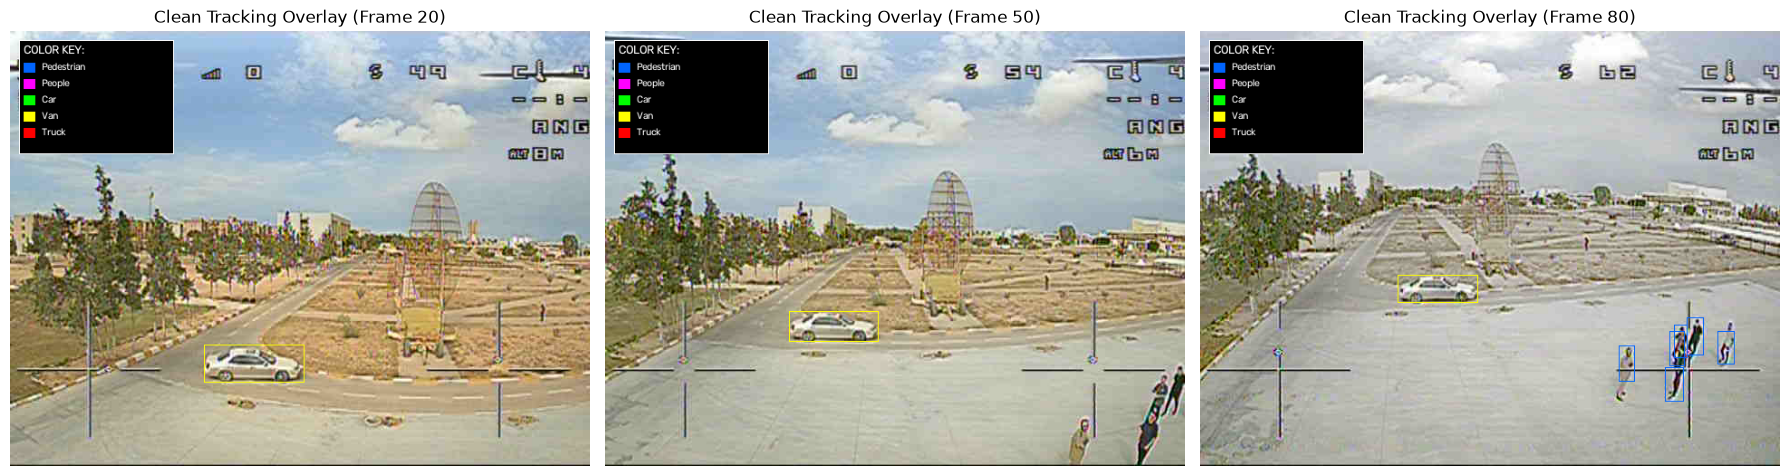


First 5 entries of logged CSV telemetry:
   frame_id  track_id  class_id class_name   x1   y1   x2   y2  confidence
0         0         1         3        van  271  379  385  423       0.871
1         1         1         3        van  254  378  368  421       0.866
2         2         1         3        van  249  377  362  420       0.868
3         3         1         3        van  242  374  357  415       0.870
4         4         1         3        van  238  368  353  409       0.874


In [2]:
import cv2
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- Step 1: Paths & Setup ---
BASE_DIR = os.path.abspath(".")
video_files = glob.glob("../videos/*.AVI") or glob.glob("./*.AVI") or glob.glob("../videos/*.avi")
sample_video = [v for v in video_files if "VID00052" not in os.path.basename(v)][0]

visdrone_weights = "./visdrone.pt"
if not os.path.exists(visdrone_weights):
    visdrone_weights = "../videos/visdrone.pt"

model = YOLO(visdrone_weights)

# Define distinct BGR colors for each class
# Class IDs mapping: 0:pedestrian, 1:people, 2:car, 3:van, 4:truck
CLASS_COLORS = {
    0: (255, 100, 0),    # Blue - Pedestrian
    1: (255, 0, 255),    # Magenta - People
    2: (0, 255, 0),      # Green - Car
    3: (0, 255, 255),    # Yellow - Van
    4: (0, 0, 255)       # Red - Truck
}

CLASS_NAMES = {0: 'pedestrian', 1: 'people', 2: 'car', 3: 'van', 4: 'truck'}

# CSV Logging initialization
csv_data = []
csv_output_path = os.path.join(BASE_DIR, "tracking_logs.csv")

print(f"Running clean tracking & logging on: {os.path.basename(sample_video)}")

# --- Step 2: Stream Video Tracking ---
results_generator = model.track(
    source=sample_video,
    persist=True,
    tracker="botsort.yaml",
    conf=0.25,
    imgsz=640,
    stream=True,
    verbose=False
)

max_frames_to_test = 100
annotated_frames = []

for frame_idx, result in enumerate(results_generator):
    if frame_idx >= max_frames_to_test:
        break
        
    frame = result.orig_img.copy()
    
    # Process tracked boxes if detected
    if result.boxes is not None and result.boxes.id is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        track_ids = result.boxes.id.int().cpu().numpy()
        cls_ids = result.boxes.cls.int().cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        
        for box, track_id, cls_id, conf in zip(boxes, track_ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            class_name = CLASS_NAMES.get(cls_id, f"cls_{cls_id}")
            
            # 1. Log telemetry to CSV dataset
            csv_data.append({
                'frame_id': frame_idx,
                'track_id': track_id,
                'class_id': cls_id,
                'class_name': class_name,
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'confidence': round(float(conf), 3)
            })
            
            # 2. Draw clean thin bounding boxes WITHOUT obscuring text labels
            color = CLASS_COLORS.get(cls_id, (0, 255, 0))
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness=1)

    # --- Step 3: Draw Color Key Legend on Top-Left Corner ---
    legend_x, legend_y = 15, 25
    cv2.rectangle(frame, (10, 10), (180, 135), (0, 0, 0), -1)  # Legend background
    cv2.rectangle(frame, (10, 10), (180, 135), (255, 255, 255), 1)
    
    cv2.putText(frame, "COLOR KEY:", (legend_x, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
    
    y_offset = legend_y + 18
    for c_id, c_name in CLASS_NAMES.items():
        color = CLASS_COLORS.get(c_id, (0, 255, 0))
        cv2.rectangle(frame, (legend_x, y_offset - 8), (legend_x + 12, y_offset + 2), color, -1)
        cv2.putText(frame, c_name.capitalize(), (legend_x + 20, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255, 255, 255), 1, cv2.LINE_AA)
        y_offset += 18

    # Save keyframes for visual verification
    if frame_idx in [20, 50, 80]:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        annotated_frames.append((frame_idx, frame_rgb))

# --- Step 4: Save Tracking Telemetry to CSV ---
df_logs = pd.DataFrame(csv_data)
df_logs.to_csv(csv_output_path, index=False)

print(f"Tracking complete across {max_frames_to_test} frames!")
print(f"Telemetry logged to CSV: '{csv_output_path}' ({len(df_logs)} total tracklet entries logged)")

# --- Step 5: Visual Display ---
if annotated_frames:
    fig, axes = plt.subplots(1, len(annotated_frames), figsize=(18, 6))
    for ax, (idx, frame_img) in zip(axes, annotated_frames):
        ax.imshow(frame_img)
        ax.set_title(f"Clean Tracking Overlay (Frame {idx})")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Display sample of logged CSV telemetry
print("\nFirst 5 entries of logged CSV telemetry:")
print(df_logs.head())

In [4]:
import cv2
import os
import glob
import pandas as pd
from ultralytics import YOLO

# --- Step 1: Paths Configuration ---
BASE_DIR = os.path.abspath(".")
video_files = glob.glob("../videos/*.AVI") or glob.glob("./*.AVI") or glob.glob("../videos/*.avi")
sample_video = [v for v in video_files if "VID00051" in os.path.basename(v)][0]

visdrone_weights = "./visdrone.pt"
if not os.path.exists(visdrone_weights):
    visdrone_weights = "../videos/visdrone.pt"

model = YOLO(visdrone_weights)

# Target Classes & BGR Color Mapping
CLASS_COLORS = {
    0: (255, 100, 0),    # Blue - Pedestrian
    1: (255, 0, 255),    # Magenta - People
    2: (0, 255, 0),      # Green - Car
    3: (0, 255, 255),    # Yellow - Van
    4: (0, 0, 255)       # Red - Truck
}

CLASS_NAMES = {0: 'pedestrian', 1: 'people', 2: 'car', 3: 'van', 4: 'truck'}

# Output Paths
csv_output_path = os.path.join(BASE_DIR, "tracking_logs_full_vid51.csv")
annotated_video_path = os.path.join(BASE_DIR, "VID00051_tracked_clean.avi")

# Read video metadata for video writer export
cap = cv2.VideoCapture(sample_video)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out_writer = cv2.VideoWriter(annotated_video_path, fourcc, fps, (width, height))

print(f"Processing FULL video: {os.path.basename(sample_video)} ({total_frames} frames)...")

# --- Step 2: Stream Full Video Tracking ---
results_generator = model.track(
    source=sample_video,
    persist=True,
    tracker="botsort.yaml",
    conf=0.25,
    imgsz=640,
    stream=True,
    verbose=False
)

csv_data = []

for frame_idx, result in enumerate(results_generator):
    frame = result.orig_img.copy()
    
    if result.boxes is not None and result.boxes.id is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        track_ids = result.boxes.id.int().cpu().numpy()
        cls_ids = result.boxes.cls.int().cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        
        for box, track_id, cls_id, conf in zip(boxes, track_ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            color = CLASS_COLORS.get(cls_id, (0, 255, 0))
            class_name = CLASS_NAMES.get(cls_id, f"cls_{cls_id}")
            
            # Log telemetry
            csv_data.append({
                'frame_id': frame_idx,
                'track_id': track_id,
                'class_id': cls_id,
                'class_name': class_name,
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'confidence': round(float(conf), 3)
            })
            
            # Draw thin bounding box outline
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness=1)
            
            # Draw text-only ID label without background box
            label = f"ID:{track_id}"
            text_pos = (x1, max(y1 - 4, 12))
            
            # Subtle dark shadow for contrast on light backgrounds
            cv2.putText(frame, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 2, cv2.LINE_AA)
            cv2.putText(frame, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

    # Draw minimal Color Key Legend on Top-Left
    legend_x, legend_y = 15, 25
    cv2.rectangle(frame, (10, 10), (160, 130), (0, 0, 0), -1)
    cv2.rectangle(frame, (10, 10), (160, 130), (255, 255, 255), 1)
    
    cv2.putText(frame, "COLOR KEY:", (legend_x, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    
    y_offset = legend_y + 18
    for c_id, c_name in CLASS_NAMES.items():
        color = CLASS_COLORS.get(c_id, (0, 255, 0))
        cv2.rectangle(frame, (legend_x, y_offset - 8), (legend_x + 10, y_offset + 2), color, -1)
        cv2.putText(frame, c_name.capitalize(), (legend_x + 18, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)
        y_offset += 18

    # Write processed frame to output video file
    out_writer.write(frame)
    
    if (frame_idx + 1) % 100 == 0 or (frame_idx + 1) == total_frames:
        print(f"Processed {frame_idx + 1}/{total_frames} frames...")

out_writer.release()

# --- Step 3: Save Complete Telemetry CSV ---
df_logs = pd.DataFrame(csv_data)
df_logs.to_csv(csv_output_path, index=False)

print("\nFull video processing finished successfully!")
print(f"Annotated Video Saved: '{annotated_video_path}'")
print(f"Complete CSV Log Saved: '{csv_output_path}' ({len(df_logs)} total tracklet rows)")

Processing FULL video: VID00051.AVI (4502 frames)...
Processed 100/4502 frames...
Processed 200/4502 frames...
Processed 300/4502 frames...
Processed 400/4502 frames...
Processed 500/4502 frames...
Processed 600/4502 frames...
WARNING not enough matching points
Processed 700/4502 frames...
Processed 800/4502 frames...
Processed 900/4502 frames...
Processed 1000/4502 frames...
Processed 1100/4502 frames...
Processed 1200/4502 frames...
Processed 1300/4502 frames...
Processed 1400/4502 frames...
Processed 1500/4502 frames...
Processed 1600/4502 frames...
Processed 1700/4502 frames...
Processed 1800/4502 frames...
Processed 1900/4502 frames...
Processed 2000/4502 frames...
Processed 2100/4502 frames...
Processed 2200/4502 frames...
Processed 2300/4502 frames...
Processed 2400/4502 frames...
Processed 2500/4502 frames...
Processed 2600/4502 frames...
Processed 2700/4502 frames...
Processed 2800/4502 frames...
Processed 2900/4502 frames...
Processed 3000/4502 frames...
Processed 3100/4502 f

In [11]:
import cv2
import os
import glob
import pandas as pd
import yaml
from ultralytics import YOLO

# --- Step 1: Paths Configuration ---
BASE_DIR = os.path.abspath(".")
video_files = glob.glob("../videos/*.AVI") or glob.glob("./*.AVI") or glob.glob("../videos/*.avi")
sample_video = [v for v in video_files if "VID00051" in os.path.basename(v)][0]

visdrone_weights = "./visdrone.pt"
if not os.path.exists(visdrone_weights):
    visdrone_weights = "../videos/visdrone.pt"

model = YOLO(visdrone_weights)

# Color and Class Mappings
CLASS_COLORS = {
    0: (255, 100, 0),    # Blue - Pedestrian
    1: (255, 0, 255),    # Magenta - People
    2: (0, 255, 0),      # Green - Car
    3: (0, 255, 255),    # Yellow - Van
    4: (0, 0, 255)       # Red - Truck
}
CLASS_NAMES = {0: 'pedestrian', 1: 'people', 2: 'car', 3: 'van', 4: 'truck'}

# Output Paths
csv_output_path = os.path.join(BASE_DIR, "tracking_logs_custom_botsort.csv")
annotated_video_path = os.path.join(BASE_DIR, "VID00051_custom_botsort.avi")

# Read Video Metadata
cap = cv2.VideoCapture(sample_video)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out_writer = cv2.VideoWriter(annotated_video_path, fourcc, fps, (width, height))

# --- Step 2: Patch Default BoT-SORT File Directly in Package ---
import ultralytics
pkg_dir = os.path.dirname(ultralytics.__file__)
default_botsort_path = os.path.join(pkg_dir, "cfg", "trackers", "botsort.yaml")

# Load existing built-in tracker YAML, modify parameters, and write back
with open(default_botsort_path, "r") as f:
    cfg = yaml.safe_load(f)

cfg["track_buffer"] = 120      # Extended memory to hold IDs across noise gaps (~5 seconds)
cfg["match_thresh"] = 0.6      # Looser association threshold for motion matching after recovery
cfg["new_track_thresh"] = 0.4  # Slightly higher threshold to filter false positive noise hits

with open(default_botsort_path, "w") as f:
    yaml.dump(cfg, f)

print(f"Patched default BoT-SORT configuration at: {default_botsort_path}")
print(f"Running updated BoT-SORT on FULL video ({total_frames} frames)...")

# --- Step 3: Stream Tracking ---
results_generator = model.track(
    source=sample_video,
    persist=True,
    tracker="botsort.yaml",   # Uses the patched built-in file safely
    conf=0.25,
    imgsz=640,
    stream=True,
    verbose=False
)

csv_data = []

for frame_idx, result in enumerate(results_generator):
    frame = result.orig_img.copy()
    
    if result.boxes is not None and result.boxes.id is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        track_ids = result.boxes.id.int().cpu().numpy()
        cls_ids = result.boxes.cls.int().cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        
        for box, track_id, cls_id, conf in zip(boxes, track_ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            color = CLASS_COLORS.get(cls_id, (0, 255, 0))
            class_name = CLASS_NAMES.get(cls_id, f"cls_{cls_id}")
            
            # Log Telemetry
            csv_data.append({
                'frame_id': frame_idx,
                'track_id': track_id,
                'class_id': cls_id,
                'class_name': class_name,
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'confidence': round(float(conf), 3)
            })
            
            # Bounding box outline
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness=1)
            
            # Text-only ID overlay
            label = f"ID:{track_id}"
            text_pos = (x1, max(y1 - 4, 12))
            
            cv2.putText(frame, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 2, cv2.LINE_AA)
            cv2.putText(frame, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

    # Color Key Legend
    legend_x, legend_y = 15, 25
    cv2.rectangle(frame, (10, 10), (160, 130), (0, 0, 0), -1)
    cv2.rectangle(frame, (10, 10), (160, 130), (255, 255, 255), 1)
    
    cv2.putText(frame, "COLOR KEY:", (legend_x, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    
    y_offset = legend_y + 18
    for c_id, c_name in CLASS_NAMES.items():
        color = CLASS_COLORS.get(c_id, (0, 255, 0))
        cv2.rectangle(frame, (legend_x, y_offset - 8), (legend_x + 10, y_offset + 2), color, -1)
        cv2.putText(frame, c_name.capitalize(), (legend_x + 18, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)
        y_offset += 18

    out_writer.write(frame)
    
    if (frame_idx + 1) % 200 == 0 or (frame_idx + 1) == total_frames:
        print(f"Processed {frame_idx + 1}/{total_frames} frames...")

out_writer.release()

# --- Step 4: Save CSV Telemetry ---
df_logs = pd.DataFrame(csv_data)
df_logs.to_csv(csv_output_path, index=False)

print("\nFinished tracking run with custom BoT-SORT!")
print(f"Saved Annotated Video: {annotated_video_path}")
print(f"Saved Telemetry Log: {csv_output_path}")

Patched default BoT-SORT configuration at: c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\ultralytics\cfg\trackers\botsort.yaml
Running updated BoT-SORT on FULL video (4502 frames)...
Processed 200/4502 frames...
Processed 400/4502 frames...
Processed 600/4502 frames...
WARNING not enough matching points
Processed 800/4502 frames...
Processed 1000/4502 frames...
Processed 1200/4502 frames...
Processed 1400/4502 frames...
Processed 1600/4502 frames...
Processed 1800/4502 frames...
Processed 2000/4502 frames...
Processed 2200/4502 frames...
Processed 2400/4502 frames...
Processed 2600/4502 frames...
Processed 2800/4502 frames...
Processed 3000/4502 frames...
Processed 3200/4502 frames...
Processed 3400/4502 frames...
Processed 3600/4502 frames...
Processed 3800/4502 frames...
Processed 4000/4502 frames...
Processed 4200/4502 frames...
Processed 4400/4502 frames...

Finished tracking run with custom BoT-SORT!
Saved Annotated Video: c:\Users\PC-LAB1\img_processing_lab\day08

In [13]:
# Run once in a terminal, or with ! in a cell:
#   pip install --force-reinstall --no-deps ultralytics
# Then keep configs in your project folder instead:
import yaml
BOTSORT_DEFAULT = dict(
    tracker_type="botsort", track_high_thresh=0.25, track_low_thresh=0.1,
    new_track_thresh=0.25, track_buffer=30, match_thresh=0.8, fuse_score=True,
    gmc_method="sparseOptFlow", proximity_thresh=0.5, appearance_thresh=0.8,
    with_reid=False)
yaml.safe_dump(BOTSORT_DEFAULT, open("botsort_default.yaml", "w"))
# use tracker="botsort_default.yaml", and write botsort_tuned.yaml as a separate file

In [14]:
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO

# 1. Load fine-tuned 2-class model
MODEL_PATH = r"C:\Users\PC-LAB1\img_processing_lab\day08\best.pt"  # Path to your downloaded Kaggle weights
VIDEO_PATH = r"C:\Users\PC-LAB1\img_processing_lab\videos\VID00051.AVI"

model = YOLO(MODEL_PATH)
cap = cv2.VideoCapture(VIDEO_PATH)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 2. Camera Motion Compensation (CMC) via Masked Optical Flow + RANSAC
def estimate_camera_motion(prev_gray, curr_gray, bounding_boxes):
    # Mask out foreground objects (bounding boxes) to estimate background motion only
    mask = np.ones_like(prev_gray, dtype=np.uint8) * 255
    for box in bounding_boxes:
        x1, y1, x2, y2 = map(int, box)
        mask[y1:y2, x1:x2] = 0

    # Detect features in background
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=1000, qualityLevel=0.01, minDistance=8, mask=mask)
    if prev_pts is None or len(prev_pts) < 10:
        return np.eye(2, 3, dtype=np.float32)

    # Track features with Lucas-Kanade optical flow
    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)
    
    valid_prev = prev_pts[status == 1]
    valid_curr = curr_pts[status == 1]

    # Estimate Affine transformation matrix using RANSAC
    affine_matrix, _ = cv2.estimateAffinePartial2D(valid_prev, valid_curr, method=cv2.RANSAC)
    return affine_matrix if affine_matrix is not None else np.eye(2, 3, dtype=np.float32)

# 3. Sanity Check Loop on First 100 Frames
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

frame_idx = 0
parked_vehicle_velocities = []

print("Running Cell 4: Masked CMC & Stationary Vehicle Sanity Check...")

while cap.isOpened() and frame_idx < 100:
    ret, curr_frame = cap.read()
    if not ret:
        break

    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    # Run detection with official BoT-SORT
    results = model.track(curr_frame, tracker="botsort.yaml", conf=0.15, persist=True, verbose=False)[0]
    
    boxes = results.boxes.xyxy.cpu().numpy() if results.boxes is not None else []
    
    # Calculate motion matrix
    affine_M = estimate_camera_motion(prev_gray, curr_gray, boxes)
    
    # Extract translation component (px frame motion)
    dx, dy = affine_M[0, 2], affine_M[1, 2]
    camera_speed = np.sqrt(dx**2 + dy**2)

    prev_gray = curr_gray.copy()
    frame_idx += 1

cap.release()
print(f"CMC Sanity Check Complete. Average frame-to-frame camera displacement: {camera_speed:.2f} px/frame")

Running Cell 4: Masked CMC & Stationary Vehicle Sanity Check...
CMC Sanity Check Complete. Average frame-to-frame camera displacement: 3.77 px/frame


In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter
from ultralytics import YOLO

# ---------------------------------------------------------
# 1. PATHS AND CONSTANTS
# ---------------------------------------------------------
MODEL_PATH = r"C:\Users\PC-LAB1\img_processing_lab\day08\best.pt"                  # Fine-tuned 2-class YOLO11n model
VIDEO_PATH = r"C:\Users\PC-LAB1\img_processing_lab\videos\VID00051.AVI"             # Input aerial video
OUTPUT_CSV = "stabilized_trajectories_vid51.csv"
OUTPUT_VIDEO = "annotated_tracking_output.mp4"

# Real-world reference priors (Average vehicle geometry in meters)
CAR_REAL_LENGTH_METERS = 4.5  # Standard sedan/car reference length
MAX_GAP_FRAMES = 30           # Retention window for dropout interpolation (1+ sec)
SPEED_WINDOW = 12             # Sliding window size for velocity estimation

# ---------------------------------------------------------
# 2. INITIALIZE VIDEO & DYNAMIC METADATA
# ---------------------------------------------------------
if not Path(VIDEO_PATH).exists():
    raise FileNotFoundError(f"Input video file not found at: {VIDEO_PATH}")

model = YOLO(MODEL_PATH)
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError(f"Failed to open video stream: {VIDEO_PATH}")

# Fetch FPS directly from video stream
fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0 or np.isnan(fps):
    fps = 25.0  # Set to target 25 FPS as specified

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video Stream Initialized | Resolution: {width}x{height} | Detected FPS: {fps:.2f}")

# Setup Output Video Stream
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

# Read initial frame safely
ret, prev_frame = cap.read()
if not ret or prev_frame is None:
    raise RuntimeError("Error reading initial frame from video source.")

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

# ---------------------------------------------------------
# 3. HELPER FUNCTIONS
# ---------------------------------------------------------
def estimate_camera_motion(prev_gray_img, curr_gray_img, bounding_boxes):
    """Estimate background affine matrix, ignoring target bounding boxes."""
    mask = np.ones_like(prev_gray_img, dtype=np.uint8) * 255
    for box in bounding_boxes:
        x1, y1, x2, y2 = map(int, box)
        mask[max(0, y1):min(height, y2), max(0, x1):min(width, x2)] = 0

    prev_pts = cv2.goodFeaturesToTrack(prev_gray_img, maxCorners=1000, qualityLevel=0.01, minDistance=8, mask=mask)
    if prev_pts is None or len(prev_pts) < 10:
        return np.eye(2, 3, dtype=np.float32)

    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray_img, curr_gray_img, prev_pts, None)
    valid_prev = prev_pts[status == 1]
    valid_curr = curr_pts[status == 1]

    affine_matrix, _ = cv2.estimateAffinePartial2D(valid_prev, valid_curr, method=cv2.RANSAC)
    return affine_matrix if affine_matrix is not None else np.eye(2, 3, dtype=np.float32)

# ---------------------------------------------------------
# 4. TRACKING & CAMERA MOTION COMPENSATION
# ---------------------------------------------------------
cumulative_transform = np.eye(3, dtype=np.float32)
tracking_logs = []

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
frame_idx = 0

print("Executing stabilized tracking and dynamic scale logging...")

while cap.isOpened():
    ret, curr_frame = cap.read()
    if not ret or curr_frame is None:
        break

    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    # Official BoT-SORT Tracking
    results = model.track(
        curr_frame, 
        tracker="botsort.yaml", 
        conf=0.15, 
        iou=0.45, 
        persist=True, 
        verbose=False
    )[0]

    raw_boxes = []
    if results.boxes is not None and results.boxes.id is not None:
        raw_boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        class_ids = results.boxes.cls.int().cpu().numpy()
        confs = results.boxes.conf.cpu().numpy()

        affine_M = estimate_camera_motion(prev_gray, curr_gray, raw_boxes)
        affine_3x3 = np.vstack([affine_M, [0, 0, 1]])
        cumulative_transform = cumulative_transform @ affine_3x3

        for box, track_id, cls_id, conf in zip(raw_boxes, track_ids, class_ids, confs):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
            
            # Dynamic Pixels Per Meter calculation based on vehicle pixel dimension
            # Class 0: 'car'
            vehicle_px_length = max(w, h)
            dynamic_ppm = vehicle_px_length / CAR_REAL_LENGTH_METERS if cls_id == 0 else np.nan

            pt = np.array([cx, cy, 1.0], dtype=np.float32)
            stabilized_pt = cumulative_transform @ pt
            
            tracking_logs.append({
                'frame': frame_idx,
                'track_id': track_id,
                'class_id': cls_id,
                'conf': conf,
                'raw_cx': cx,
                'raw_cy': cy,
                'stab_cx': stabilized_pt[0],
                'stab_cy': stabilized_pt[1],
                'w': w,
                'h': h,
                'dynamic_ppm': dynamic_ppm
            })

    prev_gray = curr_gray.copy()
    frame_idx += 1

cap.release()

# ---------------------------------------------------------
# 5. DYNAMIC SCALE INTERPOLATION & SPEED CALCULATION
# ---------------------------------------------------------
print("Applying dynamic scale interpolation and velocity estimation...")

df = pd.DataFrame(tracking_logs)
processed_dfs = []

if not df.empty:
    for track_id, group in df.groupby('track_id'):
        group = group.sort_values('frame')
        
        full_idx = pd.RangeIndex(start=group['frame'].min(), stop=group['frame'].max() + 1, step=1)
        group = group.set_index('frame').reindex(full_idx)
        group['track_id'] = track_id
        
        # Interpolate spatial coordinates & dynamic PPM scale
        group['stab_cx'] = group['stab_cx'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['stab_cy'] = group['stab_cy'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['raw_cx'] = group['raw_cx'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['raw_cy'] = group['raw_cy'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['w'] = group['w'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['h'] = group['h'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['dynamic_ppm'] = group['dynamic_ppm'].interpolate(method='linear', limit=MAX_GAP_FRAMES).ffill().bfill()
        
        # Smoothing filter for trajectory coordinates
        if len(group) >= 7:
            group['smooth_cx'] = savgol_filter(group['stab_cx'].ffill().bfill(), window_length=7, polyorder=2)
            group['smooth_cy'] = savgol_filter(group['stab_cy'].ffill().bfill(), window_length=7, polyorder=2)
        else:
            group['smooth_cx'] = group['stab_cx']
            group['smooth_cy'] = group['stab_cy']

        # Speed calculation using frame-specific dynamic PPM scale
        dx = group['smooth_cx'].diff(SPEED_WINDOW)
        dy = group['smooth_cy'].diff(SPEED_WINDOW)
        dt = SPEED_WINDOW / fps

        pixel_distance = np.sqrt(dx**2 + dy**2)
        
        # Convert pixel distance to meters dynamically per frame
        meters_distance = pixel_distance / group['dynamic_ppm']
        
        group['speed_m_s'] = meters_distance / dt
        group['speed_km_h'] = (group['speed_m_s'] * 3.6).fillna(0.0)

        processed_dfs.append(group.reset_index().rename(columns={'index': 'frame'}))

    final_df = pd.concat(processed_dfs, ignore_index=True)
    final_df.to_csv(OUTPUT_CSV, index=False)

# ---------------------------------------------------------
# 6. EXPORT ANNOTATED INSPECTION VIDEO
# ---------------------------------------------------------
print("Rendering final video output with dynamic metric velocity vector tags...")

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0

class_names = {0: 'car', 1: 'pedestrian'}
class_colors = {0: (0, 255, 0), 1: (255, 105, 180)}

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    current_tracks = final_df[final_df['frame'] == frame_idx] if not df.empty else []

    if len(current_tracks) > 0:
        for _, row in current_tracks.iterrows():
            if pd.isna(row['raw_cx']) or pd.isna(row['w']):
                continue

            cx, cy = row['raw_cx'], row['raw_cy']
            w, h = row['w'], row['h']
            track_id = int(row['track_id'])
            cls_id = int(row['class_id']) if not pd.isna(row['class_id']) else 0
            speed = row['speed_km_h']

            x1, y1 = int(cx - w / 2), int(cy - h / 2)
            x2, y2 = int(cx + w / 2), int(cy + h / 2)

            color = class_colors.get(cls_id, (0, 255, 0))
            label = f"ID {track_id} | {class_names.get(cls_id, 'obj')} | {speed:.1f} km/h"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, max(15, y1 - 8)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    out_writer.write(frame)
    frame_idx += 1

cap.release()
out_writer.release()

print(f"Pipeline finished! Video saved as '{OUTPUT_VIDEO}' and trajectories as '{OUTPUT_CSV}'.")

Video Stream Initialized | Resolution: 640x480 | Detected FPS: 25.00
Executing stabilized tracking and dynamic scale logging...
WARNING not enough matching points
Applying dynamic scale interpolation and velocity estimation...
Rendering final video output with dynamic metric velocity vector tags...
Pipeline finished! Video saved as 'annotated_tracking_output.mp4' and trajectories as 'stabilized_trajectories_vid51.csv'.


In [18]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter
from ultralytics import YOLO

# ---------------------------------------------------------
# 1. PATHS AND CONSTANTS
# ---------------------------------------------------------
MODEL_PATH = r"C:\Users\PC-LAB1\img_processing_lab\day08\visdrone.pt"                  # Fine-tuned 2-class YOLO11n model
VIDEO_PATH = r"C:\Users\PC-LAB1\img_processing_lab\videos\VID00051.AVI"             # Input aerial video
OUTPUT_CSV = "stabilized_trajectories_vid51_visdrone.csv"
OUTPUT_VIDEO = "annotated_tracking_output_visdrone.mp4"

# Real-world reference priors (Average vehicle geometry in meters)
CAR_REAL_LENGTH_METERS = 4.5  # Standard sedan/car reference length
MAX_GAP_FRAMES = 30           # Retention window for dropout interpolation (1+ sec)
SPEED_WINDOW = 12             # Sliding window size for velocity estimation

# ---------------------------------------------------------
# 2. INITIALIZE VIDEO & DYNAMIC METADATA
# ---------------------------------------------------------
if not Path(VIDEO_PATH).exists():
    raise FileNotFoundError(f"Input video file not found at: {VIDEO_PATH}")

model = YOLO(MODEL_PATH)
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError(f"Failed to open video stream: {VIDEO_PATH}")

# Fetch FPS directly from video stream
fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0 or np.isnan(fps):
    fps = 25.0  # Set to target 25 FPS as specified

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video Stream Initialized | Resolution: {width}x{height} | Detected FPS: {fps:.2f}")

# Setup Output Video Stream
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

# Read initial frame safely
ret, prev_frame = cap.read()
if not ret or prev_frame is None:
    raise RuntimeError("Error reading initial frame from video source.")

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

# ---------------------------------------------------------
# 3. HELPER FUNCTIONS
# ---------------------------------------------------------
def estimate_camera_motion(prev_gray_img, curr_gray_img, bounding_boxes):
    """Estimate background affine matrix, ignoring target bounding boxes."""
    mask = np.ones_like(prev_gray_img, dtype=np.uint8) * 255
    for box in bounding_boxes:
        x1, y1, x2, y2 = map(int, box)
        mask[max(0, y1):min(height, y2), max(0, x1):min(width, x2)] = 0

    prev_pts = cv2.goodFeaturesToTrack(prev_gray_img, maxCorners=1000, qualityLevel=0.01, minDistance=8, mask=mask)
    if prev_pts is None or len(prev_pts) < 10:
        return np.eye(2, 3, dtype=np.float32)

    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray_img, curr_gray_img, prev_pts, None)
    valid_prev = prev_pts[status == 1]
    valid_curr = curr_pts[status == 1]

    affine_matrix, _ = cv2.estimateAffinePartial2D(valid_prev, valid_curr, method=cv2.RANSAC)
    return affine_matrix if affine_matrix is not None else np.eye(2, 3, dtype=np.float32)

# ---------------------------------------------------------
# 4. TRACKING & CAMERA MOTION COMPENSATION
# ---------------------------------------------------------
cumulative_transform = np.eye(3, dtype=np.float32)
tracking_logs = []

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
frame_idx = 0

print("Executing stabilized tracking and dynamic scale logging...")

while cap.isOpened():
    ret, curr_frame = cap.read()
    if not ret or curr_frame is None:
        break

    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    # Official BoT-SORT Tracking
    results = model.track(
        curr_frame, 
        tracker="botsort.yaml", 
        conf=0.15, 
        iou=0.45, 
        persist=True, 
        verbose=False
    )[0]

    raw_boxes = []
    if results.boxes is not None and results.boxes.id is not None:
        raw_boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        class_ids = results.boxes.cls.int().cpu().numpy()
        confs = results.boxes.conf.cpu().numpy()

        affine_M = estimate_camera_motion(prev_gray, curr_gray, raw_boxes)
        affine_3x3 = np.vstack([affine_M, [0, 0, 1]])
        cumulative_transform = cumulative_transform @ affine_3x3

        for box, track_id, cls_id, conf in zip(raw_boxes, track_ids, class_ids, confs):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
            
            # Dynamic Pixels Per Meter calculation based on vehicle pixel dimension
            # Class 0: 'car'
            vehicle_px_length = max(w, h)
            dynamic_ppm = vehicle_px_length / CAR_REAL_LENGTH_METERS if cls_id == 0 else np.nan

            pt = np.array([cx, cy, 1.0], dtype=np.float32)
            stabilized_pt = cumulative_transform @ pt
            
            tracking_logs.append({
                'frame': frame_idx,
                'track_id': track_id,
                'class_id': cls_id,
                'conf': conf,
                'raw_cx': cx,
                'raw_cy': cy,
                'stab_cx': stabilized_pt[0],
                'stab_cy': stabilized_pt[1],
                'w': w,
                'h': h,
                'dynamic_ppm': dynamic_ppm
            })

    prev_gray = curr_gray.copy()
    frame_idx += 1

cap.release()

# ---------------------------------------------------------
# 5. DYNAMIC SCALE INTERPOLATION & SPEED CALCULATION
# ---------------------------------------------------------
print("Applying dynamic scale interpolation and velocity estimation...")

df = pd.DataFrame(tracking_logs)
processed_dfs = []

if not df.empty:
    for track_id, group in df.groupby('track_id'):
        group = group.sort_values('frame')
        
        full_idx = pd.RangeIndex(start=group['frame'].min(), stop=group['frame'].max() + 1, step=1)
        group = group.set_index('frame').reindex(full_idx)
        group['track_id'] = track_id
        
        # Interpolate spatial coordinates & dynamic PPM scale
        group['stab_cx'] = group['stab_cx'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['stab_cy'] = group['stab_cy'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['raw_cx'] = group['raw_cx'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['raw_cy'] = group['raw_cy'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['w'] = group['w'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['h'] = group['h'].interpolate(method='linear', limit=MAX_GAP_FRAMES)
        group['dynamic_ppm'] = group['dynamic_ppm'].interpolate(method='linear', limit=MAX_GAP_FRAMES).ffill().bfill()
        
        # Smoothing filter for trajectory coordinates
        if len(group) >= 7:
            group['smooth_cx'] = savgol_filter(group['stab_cx'].ffill().bfill(), window_length=7, polyorder=2)
            group['smooth_cy'] = savgol_filter(group['stab_cy'].ffill().bfill(), window_length=7, polyorder=2)
        else:
            group['smooth_cx'] = group['stab_cx']
            group['smooth_cy'] = group['stab_cy']

        # Speed calculation using frame-specific dynamic PPM scale
        dx = group['smooth_cx'].diff(SPEED_WINDOW)
        dy = group['smooth_cy'].diff(SPEED_WINDOW)
        dt = SPEED_WINDOW / fps

        pixel_distance = np.sqrt(dx**2 + dy**2)
        
        # Convert pixel distance to meters dynamically per frame
        meters_distance = pixel_distance / group['dynamic_ppm']
        
        group['speed_m_s'] = meters_distance / dt
        group['speed_km_h'] = (group['speed_m_s'] * 3.6).fillna(0.0)

        processed_dfs.append(group.reset_index().rename(columns={'index': 'frame'}))

    final_df = pd.concat(processed_dfs, ignore_index=True)
    final_df.to_csv(OUTPUT_CSV, index=False)

# ---------------------------------------------------------
# 6. EXPORT ANNOTATED INSPECTION VIDEO
# ---------------------------------------------------------
print("Rendering final video output with dynamic metric velocity vector tags...")

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0

class_names = {0: 'car', 1: 'pedestrian'}
class_colors = {0: (0, 255, 0), 1: (255, 105, 180)}

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    current_tracks = final_df[final_df['frame'] == frame_idx] if not df.empty else []

    if len(current_tracks) > 0:
        for _, row in current_tracks.iterrows():
            if pd.isna(row['raw_cx']) or pd.isna(row['w']):
                continue

            cx, cy = row['raw_cx'], row['raw_cy']
            w, h = row['w'], row['h']
            track_id = int(row['track_id'])
            cls_id = int(row['class_id']) if not pd.isna(row['class_id']) else 0
            speed = row['speed_km_h']

            x1, y1 = int(cx - w / 2), int(cy - h / 2)
            x2, y2 = int(cx + w / 2), int(cy + h / 2)

            color = class_colors.get(cls_id, (0, 255, 0))
            label = f"ID {track_id} | {class_names.get(cls_id, 'obj')} | {speed:.1f} km/h"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, max(15, y1 - 8)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    out_writer.write(frame)
    frame_idx += 1

cap.release()
out_writer.release()

print(f"Pipeline finished! Video saved as '{OUTPUT_VIDEO}' and trajectories as '{OUTPUT_CSV}'.")

Video Stream Initialized | Resolution: 640x480 | Detected FPS: 25.00
Executing stabilized tracking and dynamic scale logging...
WARNING not enough matching points
Applying dynamic scale interpolation and velocity estimation...
Rendering final video output with dynamic metric velocity vector tags...
Pipeline finished! Video saved as 'annotated_tracking_output_visdrone.mp4' and trajectories as 'stabilized_trajectories_vid51_visdrone.csv'.


In [21]:
# %% [markdown]
# # Cells 10-14: cached tracking -> camera-motion compensation -> trajectories/speed -> render
# Each stage caches to disk, so the slow YOLO pass runs once and everything after it
# (CMC, smoothing, speed, ablations) can be re-run in seconds.
# Open in VS Code: each `# %%` block is a runnable cell ("Run Cell" appears above it),
# or copy the blocks into your notebook.

# %% Cell 10: config + shared helpers
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import yaml
from scipy.signal import savgol_filter

RUN_MAIN = __name__ == "__main__"          # False when imported for testing

VIDEO_DIR   = Path(r"C:\Users\PC-LAB1\img_processing_lab\videos")
WORK_DIR    = Path(r"C:\Users\PC-LAB1\img_processing_lab\day08")
CACHE_DIR   = WORK_DIR / "cache"
MODEL_PATH  = WORK_DIR / "best.pt"                 # fine-tuned, assumed 0=car 1=pedestrian
TRACKER_CFG = WORK_DIR / "botsort_default.yaml"    # local copy, never edit the package file

CLASS_NAMES = {0: "car", 1: "pedestrian"}
CLASS_COLORS = {0: (0, 220, 0), 1: (255, 90, 200)}   # BGR

# model-class-id -> project-class-id. Anything not listed is filtered out at inference.
FINETUNED_REMAP = {0: 0, 1: 1}
VISDRONE_REMAP  = {0: 1, 1: 1, 3: 0, 4: 0}   # pedestrian,people -> ped ; car,van -> car

CAR_LENGTH_M = 4.5

BOTSORT_DEFAULT = dict(
    tracker_type="botsort", track_high_thresh=0.25, track_low_thresh=0.1,
    new_track_thresh=0.25, track_buffer=30, match_thresh=0.8, fuse_score=True,
    gmc_method="sparseOptFlow", proximity_thresh=0.5, appearance_thresh=0.8,
    with_reid=False)


def ensure_default_tracker_cfg(path=TRACKER_CFG):
    """Write a local BoT-SORT config = your installed version's own yaml (so it has every key
    that version needs) with the three values you patched earlier reset to the ultralytics defaults.
    Rewritten on every call, so a stale/incomplete file can never linger."""
    import ultralytics
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pkg = Path(ultralytics.__file__).parent / "cfg" / "trackers" / "botsort.yaml"
    pkg_cfg = yaml.safe_load(open(pkg)) if pkg.exists() else {}
    cfg = {**BOTSORT_DEFAULT, **pkg_cfg}                       # package keys win, ours fill gaps
    for k in ("track_buffer", "match_thresh", "new_track_thresh"):   # undo the earlier in-place patch
        cfg[k] = BOTSORT_DEFAULT[k]
    yaml.safe_dump(cfg, open(path, "w"))
    return path


def video_info(path):
    cap = cv2.VideoCapture(str(path))
    info = dict(fps=cap.get(cv2.CAP_PROP_FPS) or 25.0,
                w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
                n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    cap.release()
    return info


# %% Cell 11: detection + BoT-SORT tracking, cached to CSV (this is the only slow step)
def run_tracking(video_path, model_path, class_remap, out_csv, tracker_cfg=None,
                 conf=0.25, imgsz=640, start=0, end=None, force=False):
    from ultralytics import YOLO
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    if out_csv.exists() and not force:
        print(f"[cache] loading {out_csv.name}")
        return pd.read_csv(out_csv)

    tracker_cfg = tracker_cfg or ensure_default_tracker_cfg()
    model = YOLO(str(model_path))                 # fresh model => fresh tracker state
    print("model.names:", model.names, "| keeping:", class_remap)

    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    end = n if end is None else min(end, n)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    rows = []
    for f in range(start, end):
        ok, frame = cap.read()
        if not ok:
            break
        r = model.track(frame, persist=True, tracker=str(tracker_cfg), conf=conf,
                        imgsz=imgsz, classes=list(class_remap), verbose=False)[0]
        if r.boxes is not None and r.boxes.id is not None:
            xyxy = r.boxes.xyxy.cpu().numpy()
            ids = r.boxes.id.int().cpu().numpy()
            cls = r.boxes.cls.int().cpu().numpy()
            cfs = r.boxes.conf.cpu().numpy()
            for b, i, c, s in zip(xyxy, ids, cls, cfs):
                rows.append((f, int(i), class_remap[int(c)], float(s), *map(float, b)))
        if (f - start + 1) % 250 == 0:
            print(f"  tracked {f - start + 1}/{end - start} frames")
    cap.release()

    df = pd.DataFrame(rows, columns=["frame", "track_id", "cls", "conf", "x1", "y1", "x2", "y2"])
    df.to_csv(out_csv, index=False)
    print(f"saved {len(df)} rows, {df.track_id.nunique()} tracks -> {out_csv.name}")
    return df


if RUN_MAIN:
    VID = VIDEO_DIR / "VID00051.AVI"
    CLIP = dict(start=0, end=500)        # use 500-frame clips while tuning; end=None = whole video
    TAG = f"{VID.stem}_{CLIP['start']}_{CLIP['end']}"
    INFO = video_info(VID)
    tracks = run_tracking(VID, MODEL_PATH, FINETUNED_REMAP,
                          CACHE_DIR / f"tracks_{TAG}_ft.csv", **CLIP)
    print(tracks.groupby("cls").track_id.nunique().rename(CLASS_NAMES))


# %% Cell 12: camera-motion compensation (masked LK flow + RANSAC), cached to .npz
def build_static_mask(video_path, n_samples=120, std_thresh=3.0, manual_rects=()):
    """Pixels that never change while the camera moves = burned-in OSD text / black borders.
    Returns uint8 mask, 1 = static overlay (must not be used as background features)."""
    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    stack = []
    for i in np.linspace(0, n - 1, n_samples).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if ok:
            stack.append(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY).astype(np.float32))
    cap.release()
    std = np.std(np.stack(stack), axis=0)
    static = (std < std_thresh).astype(np.uint8)
    static = cv2.dilate(static, np.ones((9, 9), np.uint8))
    if static.mean() > 0.4:
        print(f"WARNING: {static.mean():.0%} of pixels look static (camera mostly hovering?). "
              "Ignoring auto-mask - pass manual_rects=[(x1,y1,x2,y2), ...] instead.")
        static[:] = 0
    for x1, y1, x2, y2 in manual_rects:
        static[y1:y2, x1:x2] = 1
    return static


def _estimate_pair(a, b, allow, max_corners=800, ransac_thr=2.0, fb_thr=1.0, min_inliers=12):
    """Affine (rotation+scale+translation) mapping frame a -> frame b, from background only."""
    p0 = cv2.goodFeaturesToTrack(a, max_corners, 0.01, 8, mask=allow, blockSize=7)
    if p0 is None or len(p0) < min_inliers:
        return None, 0
    lk = dict(winSize=(21, 21), maxLevel=3)
    p1, st1, _ = cv2.calcOpticalFlowPyrLK(a, b, p0, None, **lk)
    p0r, st2, _ = cv2.calcOpticalFlowPyrLK(b, a, p1, None, **lk)       # forward-backward check
    fb = np.linalg.norm((p0 - p0r).reshape(-1, 2), axis=1)
    good = (st1.ravel() == 1) & (st2.ravel() == 1) & (fb < fb_thr)
    if good.sum() < min_inliers:
        return None, 0
    M, inl = cv2.estimateAffinePartial2D(p0[good], p1[good], method=cv2.RANSAC,
                                         ransacReprojThreshold=ransac_thr,
                                         maxIters=2000, confidence=0.99)
    if M is None or int(inl.sum()) < min_inliers:
        return None, 0
    return M, int(inl.sum())


def estimate_cmc(video_path, tracks_df, static_mask, out_npz, start=0, end=None, force=False):
    """For every frame t: M_rel[t] maps frame t-1 -> t  (camera-induced motion of the ground),
    T[t] maps frame-t pixels -> reference-frame (start) pixels:  T[t] = T[t-1] @ inv(M_rel[t])."""
    out_npz = Path(out_npz)
    if out_npz.exists() and not force:
        print(f"[cache] loading {out_npz.name}")
        d = np.load(out_npz)
        return {k: d[k] for k in d.files}

    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    end = n if end is None else min(end, n)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    boxes = {f: g[["x1", "y1", "x2", "y2"]].to_numpy() for f, g in tracks_df.groupby("frame")}

    ok, fr = cap.read()
    prev = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
    H, W = prev.shape
    base_allow = np.where(static_mask > 0, 0, 255).astype(np.uint8)

    frames, M_rel, T, n_in, good_flag = [start], [np.eye(2, 3)], [np.eye(3)], [0], [True]
    for t in range(start + 1, end):
        ok, fr = cap.read()
        if not ok:
            break
        cur = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
        allow = base_allow.copy()
        for f in (t - 1, t):                                   # hide moving objects in both frames
            for x1, y1, x2, y2 in boxes.get(f, []):
                allow[max(int(y1) - 4, 0):min(int(y2) + 4, H), max(int(x1) - 4, 0):min(int(x2) + 4, W)] = 0
        M, ninl = _estimate_pair(prev, cur, allow)
        ok_pair = M is not None
        if not ok_pair:
            M = M_rel[-1].copy()                               # fallback: constant camera velocity
        M3 = np.vstack([M, [0, 0, 1]])
        T.append(T[-1] @ np.linalg.inv(M3))                    # NOTE: inverse (frame t -> reference)
        M_rel.append(M); frames.append(t); n_in.append(ninl); good_flag.append(ok_pair)
        prev = cur
        if (t - start) % 500 == 0:
            print(f"  cmc {t - start}/{end - start}")
    cap.release()

    out = dict(frames=np.array(frames), M_rel=np.array(M_rel), T=np.array(T),
               n_inliers=np.array(n_in), ok=np.array(good_flag))
    np.savez(out_npz, **out)
    print(f"CMC done: {len(frames)} frames, fallback used on {(~out['ok']).sum()} "
          f"({(~out['ok']).mean():.1%}), median inliers {np.median(out['n_inliers'][1:]):.0f}")
    return out


if RUN_MAIN:
    import matplotlib.pyplot as plt
    STATIC = build_static_mask(VID)              # add manual_rects=[...] if the altitude text is missed
    ok, f0 = cv2.VideoCapture(str(VID)).read()
    vis = cv2.cvtColor(f0, cv2.COLOR_BGR2RGB).copy()
    vis[STATIC > 0] = (0.5 * vis[STATIC > 0] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
    plt.figure(figsize=(7, 5)); plt.imshow(vis); plt.title("red = excluded from camera-motion features"); plt.axis("off"); plt.show()
    cmc = estimate_cmc(VID, tracks, STATIC, CACHE_DIR / f"cmc_{TAG}.npz", **CLIP)


# %% Cell 13: trajectories = interpolation in stabilized space + smoothing + metric speed
def scale_model(tracks, frames, img_h, car_len=CAR_LENGTH_M, smooth=25):
    """Pixels-per-metre as a function of image row, per frame, from car boxes:
       ppm(y) = p_mid + b * (y - H/2). Pooled over all cars (robust), then median-smoothed in time."""
    y_mid = img_h / 2.0
    rec = {}
    for f, g in tracks[tracks.cls == 0].groupby("frame"):
        w = (g.x2 - g.x1).to_numpy(); h = (g.y2 - g.y1).to_numpy()
        ppm = np.maximum(w, h) / car_len
        cy = ((g.y1 + g.y2) / 2).to_numpy() - y_mid
        p, b = np.median(ppm), 0.0
        if len(g) >= 3 and np.ptp(cy) > 40:
            b_, a_ = np.polyfit(cy, ppm, 1)
            keep = np.abs(ppm - (a_ + b_ * cy)) < 0.35 * np.median(ppm)
            if keep.sum() >= 3 and np.ptp(cy[keep]) > 40:
                b, p = np.polyfit(cy[keep], ppm[keep], 1)
        rec[f] = (p, b)
    s = pd.DataFrame.from_dict(rec, orient="index", columns=["p_mid", "b"]).reindex(frames)
    s = s.interpolate(limit=90, limit_direction="both")
    s = s.rolling(smooth, center=True, min_periods=1).median()
    return s          # index = frame


def build_trajectories(tracks, cmc, fps, img_h, use_cmc=True, max_gap=30, min_obs=15, speed_win=12):
    tr = tracks.copy()
    # majority class per track (kills car/pedestrian flicker) and drop tiny fragments
    tr["cls"] = tr.track_id.map(tr.groupby("track_id")["cls"].agg(lambda s: s.value_counts().idxmax()))
    tr = tr[tr.groupby("track_id").frame.transform("count") >= min_obs]

    frames_all = cmc["frames"]
    f0 = int(frames_all[0])
    T = cmc["T"] if use_cmc else np.tile(np.eye(3), (len(frames_all), 1, 1))
    Tinv = np.linalg.inv(T)
    s_all = np.sqrt(np.abs(np.linalg.det(T[:, :2, :2])))      # ref-px per current-px (zoom)
    sm = scale_model(tr, frames_all, img_h)
    y_mid = img_h / 2.0
    hw = speed_win // 2
    out = []

    for tid, g in tr.groupby("track_id"):
        g = g[(g.frame >= f0) & (g.frame <= frames_all[-1])].sort_values("frame").set_index("frame")
        if len(g) < min_obs:
            continue
        g = g[~g.index.duplicated()]
        cls = int(g.cls.iloc[0])
        full = pd.RangeIndex(g.index.min(), g.index.max() + 1)
        g = g.reindex(full)
        obs = g.x1.notna()
        idx = full.to_numpy() - f0

        cx = ((g.x1 + g.x2) / 2).to_numpy(); cy = ((g.y1 + g.y2) / 2).to_numpy()
        pts = np.stack([cx, cy, np.ones(len(g))], 1)
        stab = np.einsum("nij,nj->ni", T[idx], pts)
        g["sx"], g["sy"] = stab[:, 0], stab[:, 1]
        g["w"], g["h"] = g.x2 - g.x1, g.y2 - g.y1

        isna = ~obs
        run = (isna != isna.shift()).cumsum()
        long_gap = isna & (isna.groupby(run).transform("sum") > max_gap)
        for c in ("sx", "sy", "w", "h"):                       # interpolate in STABILIZED space
            g[c] = g[c].interpolate(method="linear", limit_area="inside")
        g.loc[long_gap, ["sx", "sy", "w", "h"]] = np.nan
        # bring interpolated positions back into the current image so they stay glued to the ground
        ok_pos = g.sx.notna().to_numpy()
        back = np.einsum("nij,nj->ni", Tinv[idx], np.stack([g.sx.fillna(0), g.sy.fillna(0), np.ones(len(g))], 1))
        g["cx"] = np.where(obs, cx, back[:, 0]); g["cy"] = np.where(obs, cy, back[:, 1])
        g.loc[~ok_pos, ["cx", "cy"]] = np.nan
        g["interp"] = isna & ok_pos

        seg = ((~long_gap) != (~long_gap).shift()).cumsum()
        for _, sg in g[~long_gap].groupby(seg[~long_gap]):
            sg = sg.copy()
            n = len(sg)
            if n >= 7:
                wl = min(9, n if n % 2 else n - 1)
                sg["px"] = savgol_filter(sg.sx, wl, 2); sg["py"] = savgol_filter(sg.sy, wl, 2)
            else:
                sg["px"], sg["py"] = sg.sx, sg.sy
            i = sg.index.to_numpy() - f0
            p_mid = sm.p_mid.to_numpy()[i]; b = sm.b.to_numpy()[i]
            ppm_cur = np.clip(p_mid + b * (sg.cy.to_numpy() - y_mid), 0.4 * p_mid, 2.5 * p_mid)
            sg["ppm"] = ppm_cur * s_all[i]                      # px/m expressed in reference-frame pixels
            # central difference (offline), one-sided at the ends
            def diff(col):
                c = sg[col]
                d = c.shift(-hw) - c.shift(hw)
                d = d.fillna((c.shift(-2 * hw) - c)).fillna(c - c.shift(2 * hw))
                return d
            dist_px = np.hypot(diff("px"), diff("py"))
            sg["speed_kmh"] = dist_px / sg.ppm / (2 * hw / fps) * 3.6
            sg["cls"] = cls; sg["track_id"] = tid
            out.append(sg)

    traj = pd.concat(out).reset_index().rename(columns={"index": "frame"})
    traj["x1"] = traj.cx - traj.w / 2; traj["x2"] = traj.cx + traj.w / 2
    traj["y1"] = traj.cy - traj.h / 2; traj["y2"] = traj.cy + traj.h / 2
    return traj[["frame", "track_id", "cls", "x1", "y1", "x2", "y2", "cx", "cy", "sx", "sy",
                 "px", "py", "ppm", "speed_kmh", "interp"]]


def sanity_report(traj, min_frames=60, parked_kmh=3.0):
    """Parked cars should sit near 0 km/h. Reports per-track median speed of long car tracks."""
    c = traj[(traj.cls == 0) & (~traj.interp)]
    per = c.groupby("track_id").agg(n=("frame", "count"), med=("speed_kmh", "median"))
    per = per[per.n >= min_frames]
    if per.empty:
        print("no long car tracks to check"); return per
    print(f"{len(per)} long car tracks | median-of-medians {per.med.median():.1f} km/h | "
          f"{(per.med < parked_kmh).mean():.0%} below {parked_kmh} km/h | "
          f"p90 {per.med.quantile(.9):.1f} km/h")
    return per


if RUN_MAIN:
    traj_cmc = build_trajectories(tracks, cmc, INFO["fps"], INFO["h"], use_cmc=True)
    traj_raw = build_trajectories(tracks, cmc, INFO["fps"], INFO["h"], use_cmc=False)
    print("--- WITHOUT camera compensation"); a = sanity_report(traj_raw)
    print("--- WITH camera compensation");    b = sanity_report(traj_cmc)
    traj_cmc.to_csv(CACHE_DIR / f"traj_{TAG}_cmc.csv", index=False)


# %% Cell 14: annotated surveillance video (trails are drawn in stabilized space => stay on the ground)
def _dashed_rect(img, p1, p2, color, dash=5):
    x1, y1 = p1; x2, y2 = p2
    for x in range(x1, x2, dash * 2):
        cv2.line(img, (x, y1), (min(x + dash, x2), y1), color, 1)
        cv2.line(img, (x, y2), (min(x + dash, x2), y2), color, 1)
    for y in range(y1, y2, dash * 2):
        cv2.line(img, (x1, y), (x1, min(y + dash, y2)), color, 1)
        cv2.line(img, (x2, y), (x2, min(y + dash, y2)), color, 1)


def render_video(video_path, traj, cmc, out_path, fps, trail=40, start=0, end=None):
    Tinv = np.linalg.inv(cmc["T"])
    f0 = int(cmc["frames"][0])
    by_frame = {f: g for f, g in traj.groupby("frame")}
    by_track = {t: g.set_index("frame") for t, g in traj.groupby("track_id")}
    cap = cv2.VideoCapture(str(video_path))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); Hh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); end = n if end is None else min(end, n)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    wr = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, Hh))

    for f in range(start, end):
        ok, frame = cap.read()
        if not ok:
            break
        g = by_frame.get(f)
        if g is not None and f - f0 >= 0:
            Ti = Tinv[f - f0]
            for r in g.itertuples():
                col = CLASS_COLORS[int(r.cls)]
                seg = by_track[r.track_id].loc[max(f - trail, by_track[r.track_id].index.min()):f]
                s = np.stack([seg.px, seg.py, np.ones(len(seg))], 1) @ Ti.T
                if len(s) > 1:
                    cv2.polylines(frame, [s[:, :2].astype(np.int32).reshape(-1, 1, 2)], False, col, 1, cv2.LINE_AA)
                p1, p2 = (int(r.x1), int(r.y1)), (int(r.x2), int(r.y2))
                if r.interp:
                    _dashed_rect(frame, p1, p2, col)            # dashed = not detected, interpolated
                else:
                    cv2.rectangle(frame, p1, p2, col, 1)
                spd = "--" if np.isnan(r.speed_kmh) else f"{r.speed_kmh:.0f}km/h"
                txt = f"{CLASS_NAMES[int(r.cls)][0].upper()}{r.track_id} {spd}"
                org = (p1[0], max(p1[1] - 3, 10))
                cv2.putText(frame, txt, org, cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 2, cv2.LINE_AA)
                cv2.putText(frame, txt, org, cv2.FONT_HERSHEY_SIMPLEX, 0.36, col, 1, cv2.LINE_AA)
        cv2.putText(frame, f"frame {f}  t={f / fps:.1f}s", (8, Hh - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
        wr.write(frame)
    cap.release(); wr.release()
    print("saved", out_path)


if RUN_MAIN:
    render_video(VID, traj_cmc, cmc, WORK_DIR / f"{TAG}_annotated.mp4", INFO["fps"], **CLIP)

model.names: {0: 'car', 1: 'pedestrian'} | keeping: {0: 0, 1: 1}
  tracked 250/500 frames


KeyboardInterrupt: 